# Notebook Description

This notebook will focus on creating models to predict delivery ratings based on driver handling characteristics. 

We begin by first selecting suitable features from the dataset to serve as our predictors, after which the dataset will be split into training and testing sets. A baseline error metric will then be established for us to compare our model performance against. Then, we will fit and compare two models, a linear model and gradient-boosted decision trees (XGBoost), against each other and the baseline. Finally, from the best performing model, we will determine the most important features according to predictive power. 

# Import

### Necessary Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

### The Dataset

In [2]:
telemetry_ratings = pd.read_csv('../data/preprocessed/telemetry_ratings_preprocessed.csv')

In [3]:
telemetry_ratings.head(3)

,Unnamed: 0,trip_id,driver_id,timestamp,max_speed_kmh,avg_speed_kmh,throttle_pct,max_steering_rate_deg_per_s,peak_fwd_x_g,peak_rear_x_g,...,traffic_condition,weather_condition,trip_duration_min,peak_long_g,peak_lat_g,delivery_dayofweek,time_of_day,rating,late_delivery_flag,rating_category
0,0,TRP-100-001,DRV100395,2026-05-19 13:05:21,27.382,20.275,47.438,139.923,0.158,0.360,...,Light,Clear,16.15,0.360,0.230,Tuesday,Noon/Early Afternoon,4.390375,1,Excellent
1,1,TRP-100-002,DRV100381,2026-04-21 16:40:06,63.910,47.545,70.517,191.011,0.411,0.460,...,Moderate,Clear,103.25,0.460,0.346,Tuesday,Late Afternoon/Evening,4.015978,1,Good
2,2,TRP-100-003,DRV100508,2026-03-07 09:03:45,47.191,34.784,50.944,183.156,0.484,0.394,...,Moderate,Clear,189.15,0.484,0.320,Saturday,Morning,3.998266,0,Good


In [4]:
telemetry_ratings[(telemetry_ratings['event_code'] != 'NONE')].shape[0]

27823

# Feature Selection

We have a total of six selected features. Notice that the absolute values for longitudinal and lateral acceleration were selected instead of their components. The same can be said for swerving, overspeed, and hard braking counts, which were used in place of the handling risk score feature. The same can be said for using average speed only, instead of combining both. This was done because having closely related features causes multicollinearity issues, which would make it harder to interpret which features are more important based on coefficient weights for linear models (which will be shown later). 

In [5]:
feats = telemetry_ratings[[
    'avg_speed_kmh',
    'peak_long_g',
    'peak_lat_g',
    'swerving_count',
    'overspeed_count',
    'hard_brake_count'
]]

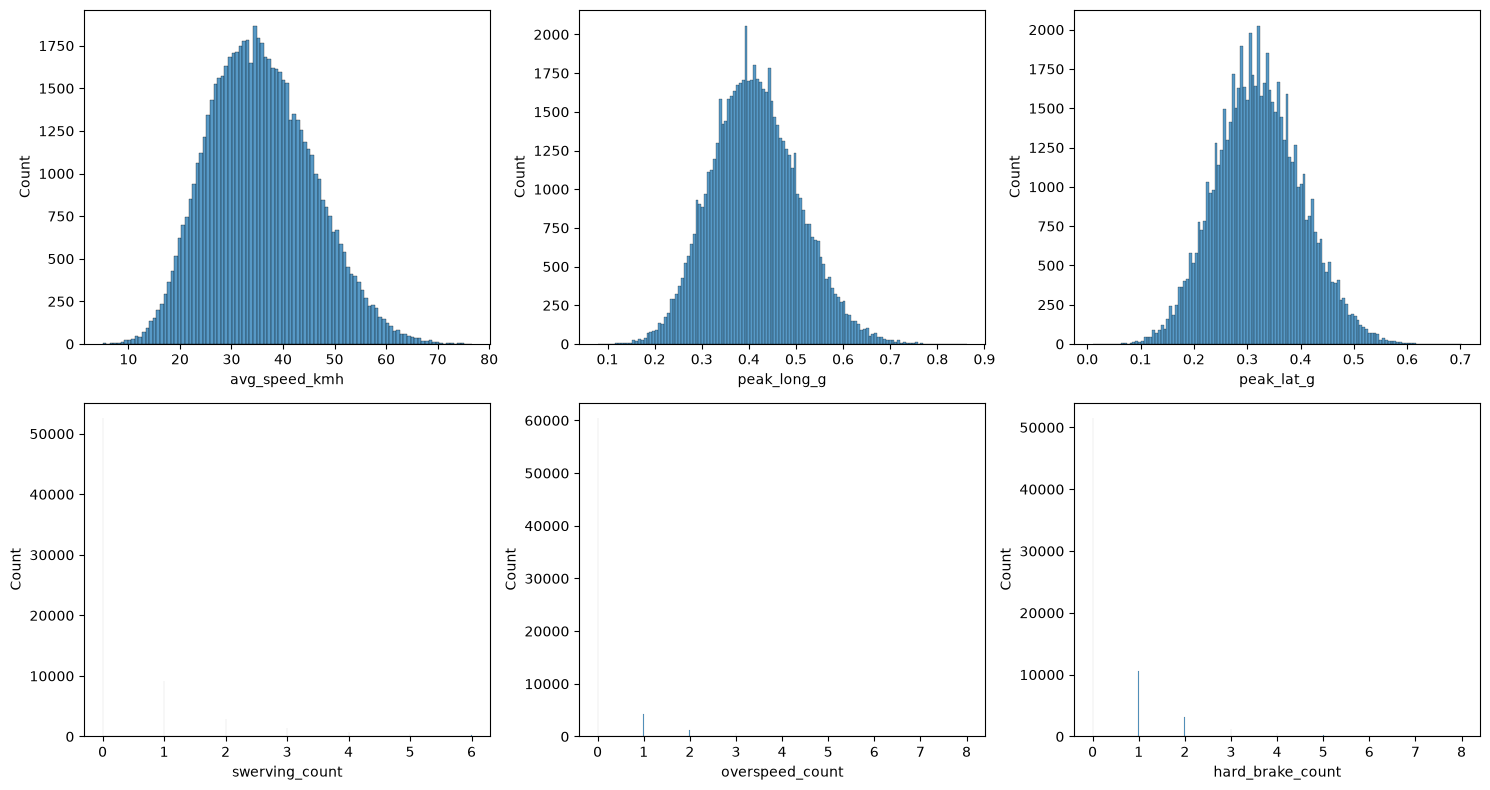

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

row = col = 0

for feat in feats.columns:
    if col > 2:
        col = 0
        row += 1
    
    sns.histplot(
        data=feats,
        x=feat,
        ax=ax[row, col]
    )

    col +=1 

plt.tight_layout()
plt.show()

The speed annd acceleration g-force values appear to be well-behaved, mostly following a bell curve with a slight skew. The *_count* features, however, appear sparse. The mass of values are concentrated near or at zero with an extremely long tail of extremes. This would severely affect how OLS will calculate the best slope by allowing rare extremes in these features to exert high leverages on the coefficients. Hence, we binarize these features to keep them stable and interpretable. 

In [7]:
telemetry_ratings['had_swerving'] = (telemetry_ratings['swerving_count'] > 0).astype(int)
telemetry_ratings['had_overspeeding'] = (telemetry_ratings['overspeed_count'] > 0).astype(int)
telemetry_ratings['had_hard_braking'] = (telemetry_ratings['hard_brake_count'] > 0).astype(int)

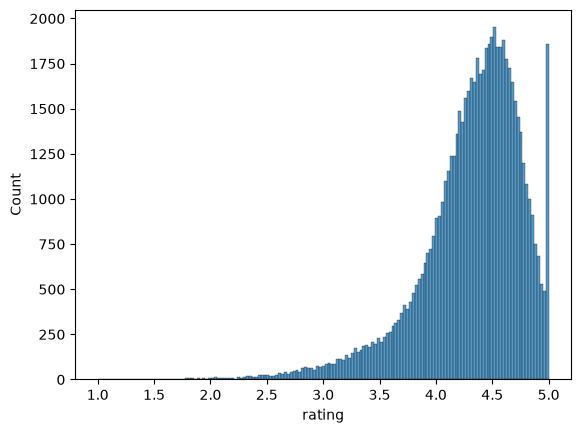

In [8]:
sns.histplot(
    data=telemetry_ratings,
    x='rating'
)

plt.show()

Our target feature, `ratings`, is bounded by the range $[1.0, 5.0]$. A model that does not know about this bound (such as OLS regression) will happily predict values like 5.4 or 0.7, which are way outside of that bound. This means that the model will just operate on the assumption that our target can take on any value along the real number line. 

To fix this, we perform a logit transformation, which is a mathematical technique that takes a constrained value (within some bounded range like [1.0, 5.0]) and 'stretches' it out so it can take on values from $-\infty$ to $\infty$ (basically the entire real number line).

$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$

In our case, as $p$ (the rescaled rating) approaches 1 (that is, rating approaches 5), the logit value shoots up toward $+\infty$ rather than just stopping at some fixed number. As $p$ approaches 0, logit shoots toward $-\infty$. 


The predictions can then be transformed back to values within the original bound using the inverse of the logit transformation using the logistic function (or sigmoid function) $\sigma(z) = \frac{1}{1 + e^{-z}}$. The result is mathematically guaranteed to land back inside $[1.0,5.0]$ no matter what the model outputs on the transformed scale. 

In [9]:
# Also round the rating values early on
telemetry_ratings['rating'] = np.round(telemetry_ratings['rating'], 2)

# Split

We then create our train and test sets, with a 70/30 split (70% training, 30% testing).

In [10]:
X = telemetry_ratings[[
    'avg_speed_kmh',
    'peak_long_g',
    'peak_lat_g',
    'had_swerving',
    'had_overspeeding',
    'had_hard_braking'
]]

y = telemetry_ratings['rating']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# Baseline

### Global Baseline Using Training Set Mean

We set a baseline value equal to the mean absolute error, which measures the sum of absolute differences between true values and values predicted by a model that only "guesses" and outputs the mean for every prediction. This is the baseline value our models need to beat. 

In [12]:
y_pred_baseline = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = root_mean_squared_error(y_test, y_pred_baseline)

print(f"Baseline MAE: {baseline_mae}")
print(f"Baseline RMSE: {baseline_rmse}")

Baseline MAE: 0.34612243152577205
Baseline RMSE: 0.46699441413145126


### Linear Model as Baseline

We'll use a standard linear regression model first with no L1/L2 regularization. Still, even without penalty terms, we perform standardization on our predictors to make coefficients more comparable (since they would all be on the same unit scale). 

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [14]:
# apply the logit transformation to y first
y_train_rescaled = (y_train - 1) / (5 - 1)
y_test_rescaled = (y_test - 1) / (5 - 1)

epsilon = 1e-4

y_train_rescaled = y_train_rescaled.clip(epsilon, 1-epsilon)
y_test_rescaled = y_test_rescaled.clip(epsilon, 1-epsilon)

y_train_logit = np.log(y_train_rescaled / (1-y_train_rescaled))
y_test_logit= np.log(y_test_rescaled / (1-y_test_rescaled))

Also, we can keep the binarized features unscaled since they already take on values 0 or 1. Scaling them is fine as it wont affect fit quality, but for interpretability reasons, we keep it as it is. 

In [15]:
cont_feat = ['avg_speed_kmh','peak_long_g','peak_lat_g']

preprocessor = ColumnTransformer(
    transformers=[
        ('scale',StandardScaler(), cont_feat)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model',LinearRegression())
    ]
)

In [16]:
pipeline.fit(X_train, y_train_logit)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['avg_speed_kmh','peak_long_g','peak_lat_g','had_swerving', 'had_overspeeding','had_hard_braking']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

##### Sample Prediction
Say we have a new observation where a driver logs a safe average speed of 45 kmh with one swerving incident. For the sake of this example, let's assume that the driver had to swerve to avoid a road hazard. The linear model predicts that the driver is likely to get a rating of 1.7, which is a bit on the "harsh" side (personally speaking) as the vehicle appears to be adhering to imposed speed limits and that the swerve was likely done at those speeds. With that, it is unlikely that the packages inside the vehicle were severely damaged for a customer to give such a low rating. We will compare this to the tree-based regressor later. 

In [17]:
test_values = pd.DataFrame({
    'avg_speed_kmh':[45.2],
    'peak_long_g':[0.2],
    'peak_lat_g':[0.45],
    'had_swerving':[1],
    'had_overspeeding':[0],
    'had_hard_braking':[0]
})

rating_pred = pipeline.predict(test_values)
print(f"Predicted rating: {rating_pred[0]:.3f}")

Predicted rating: 1.729


### Evaluation

In [18]:
y_pred_logit = pipeline.predict(X_test)

# invert the prediction back to original scale 
y_pred = 1 / (1 + np.exp(-y_pred_logit))
y_pred = 1 + 4*y_pred

linear_model_mae = mean_absolute_error(y_test, y_pred)
linear_model_rmse = root_mean_squared_error(y_test, y_pred)

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Model MAE: {linear_model_mae:.4f}")
print(f"Model RMSE: {linear_model_rmse:.4f}")

Baseline MAE: 0.3461
Model MAE: 0.2753
Model RMSE: 0.3651


The results suggest that the regression model scored a lower meaen absolute error than our baseline, which indicates that it slightly performed better than a guessing model. Later on, we will compare this to the performance of a tree-based regressor. 

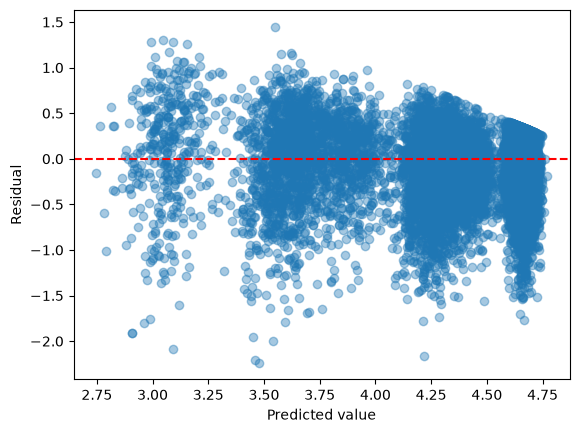

In [19]:
residuals = y_test - y_pred

plt.scatter(
    y_pred, 
    residuals,
    alpha=0.4
)

plt.axhline(0, color='red',linestyle='--')
plt.xlabel('Predicted value')
plt.ylabel('Residual')
plt.show()

Plotting the residuals of our linear model, we can see that the predicted range is narrow (~3.8 to ~4.7) compared to the target's actual range (around ~2.0 as per the histogram earlier). This indicates that OLS is being extra careful by pulling everything toward the mean since linear regression can't model the bimodal-like, bounded shape of the target data. 

There was also no funnel/fan shape in variance observed. There is also a uniform spread of negative residuals across the predicted range, just oddly bounded on the top portion. This "ceiling" effect is mostly a structural rather than a variance problem, which indicates that there are no heteroscedasticity issues. 

In [20]:
feat_names = preprocessor.get_feature_names_out().tolist()
model_coefs = pipeline['model'].coef_

feat_imp = pd.DataFrame({'feature_name':feat_names, 'coefficient':model_coefs})


In [21]:
feat_imp.sort_values(by=['coefficient'], ascending=False, key=abs)

,feature_name,coefficient
3,remainder__had_swerving,-0.841012
5,remainder__had_hard_braking,-0.744533
4,remainder__had_overspeeding,-0.579924
1,scale__peak_long_g,-0.093330
0,scale__avg_speed_kmh,0.085920
2,scale__peak_lat_g,-0.047904


Here is also a rough representation of feature importance based on regression coefficients. The `had_swerving` binary feature appears to be the feature with the largest weight among the set of predictors. This is similar to what the strip plots in the EDA notebook suggest, where ratings go down as swerving events increase. This will be examined further later on. 

### Regression using Gradient-Boosted Trees

Decision trees split data using conditions instead of literal magnitude. With that, no scaling is needed for our predictor variables. Likewise, trees also cannot predict outside of the target's range, unlike linear regression which can extrapolate an indefinite amount of values. Tree-based models are also robust to multicollinearity, since they operate on decisions and thresholds rather than assumptions on feature independence. However, the training set will be kept frozen so as to make the comparison with the linear model fair. 

This also means that we can use the non-binarized features as those could carry more signal and opens up the possibility of XGBoost finding a better split point.

In [22]:
X = telemetry_ratings[[
    'avg_speed_kmh',
    'peak_long_g',
    'peak_lat_g',
    'swerving_count',
    'overspeed_count',
    'hard_brake_count'
]]

y = telemetry_ratings['rating']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

An XGBoost regressor is instantiated with these hyperparameters by default. It has 300 individual decision trees which also randomly samples 80% of the entire data when building each tree via the `colsample_bytree` hyperparam. which helps prevents overfitting. 

In [24]:
xgb = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=300, 
    max_depth=4, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42
)

Then, we fit it on the data, predict on the test set, and evaluate performance. 

In [25]:
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Linear model MAE: {linear_model_mae:.4f}")
print(f"XGBoost MAE: {mae_xgb:.4f}")
print(f"XGBGoost RMSE: {rmse_xgb:.4f}")

Baseline MAE: 0.3461
Linear model MAE: 0.2753
XGBoost MAE: 0.2291
XGBGoost RMSE: 0.2932


The XGBoost model shows significant improvement over our baseline and the linear model's error, also with a noticeable improvement in RMSE as well. This increase in performance is likely due to how XGBoost, and decision trees in general, handles non-linear relationships, skews and outliers, compared to linear models which assume data follows some distribution. 

##### Sample Prediction

Using the same test values for the linear model earlier, the XGB regressor predicted a more reasonable rating. A modest average trip speed with a single preemptive swerve for accident avoidance resulted in a predicted rating of 4.3. 

In [26]:
test_values = pd.DataFrame({
    'avg_speed_kmh':[45.2],
    'peak_long_g':[0.2],
    'peak_lat_g':[0.45],
    'swerving_count':[1],
    'overspeed_count':[0],
    'hard_brake_count':[0]
})

rating_pred = xgb.predict(test_values)
print(f"Predicted rating: {rating_pred[0]:.3f}")

Predicted rating: 4.332


### Hyperparameter Tuning

We can go a bit further and try to determine the optimal hyperparameters for the XGBoost regressor to possibly yield a lower MAE. This can be done by pairing Grid Search with KFold cross validation. KFold splits our data literally into $k$ number of 'folds' or partitions, and iteratively trains the model on $k-1$ folds and tests it on the remaining one. Grid search, on the other hand, simply allows us to define a 'grid' of hyperparameters for us to find the best combination of values that yield a model with the best performance. Pairing this with KFold, we can exhuast this grid in hopes of finding the best combination of hyperparameters, as well as the best performing model. 

In [27]:
from sklearn.model_selection import KFold, GridSearchCV

In [28]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 400],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [29]:
base_model = XGBRegressor(
    objective='reg:absoluteerror',  
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=base_model, 
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=kf, 
    n_jobs=-1,
    verbose=2
)

Notice how negative MAE was used for scoring for the grid search. This is because GridSearchCV's scoring works by maximizing evaluation scores. So, for example, if we had MAE values 4.2 and 6, negating them to -4.2 and 6  will allow GridSearchCV to correctly select -4.2 as the better (higher) score. 

In [30]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know m

At the time of writing, the compute time was around 5 minutes. It appears that the best hyperparameter values are as follows, with 200 individual trees. More importantly, there is no meaningful improvement between the default hyperparameters we specified compared to the ones found using grid search. Nevertheless, this is a useful technique to use and perhaps a lower MAE could have been achieved, given more computing power and time. 

In [31]:
print("Best params:", grid_search.best_params_)
print("Best CV MAE:", -1 * grid_search.best_score_) 

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Best CV MAE: 0.23171499320640768


# Feature Importance

Due to a NumPy dependency issue, feature importance calculation was done using scikit-learn's permutation_importance instead of SHAP. 

In [32]:
from sklearn.inspection import permutation_importance

We use 10 repeats to ensure stability.

In [33]:
result = permutation_importance(
    grid_search.best_estimator_,
    X_test, 
    y_test, 
    scoring='neg_mean_absolute_error',
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

In [34]:
feat_imp = pd.DataFrame({
    'feature':X_test.columns,
    'importance_mean':result.importances_mean,
    'importance_stddev':result.importances_std
}).sort_values('importance_mean', ascending=False)

feat_imp

,feature,importance_mean,importance_stddev
3,swerving_count,0.081393,0.000695
5,hard_brake_count,0.069768,0.000626
4,overspeed_count,0.017054,0.000376
0,avg_speed_kmh,0.004843,0.000189
1,peak_long_g,0.004387,0.000189
2,peak_lat_g,0.001631,0.000127


The XGBoost regressor also describes swerving as a strong predictor of customer delivery ratings, having the highest importance mean among all other features. 

Overall, both models described swerving as the most important driver handling characteristic that affects customer ratings. The OLS regression model did not provide much improvement over the baseline metric, compared to the XGBoost regressor which also shows that it was a better choice for this task. 

#### Saving the Model

In [36]:
import joblib 

joblib.dump(xgb, '../models/ratings_xgbregressor.joblib')

['../models/ratings_xgbregressor.joblib']